# Univariate Analysis — Numerical Variables 📊

> Analysis of **one numerical variable** at a time.

**Examples:** `Age`, `Salary`, `Height`, `Marks`, `Price`

---

## 1. Types

* **Discrete** → Countable values: `1, 2, 3...`
* **Continuous** → Any value within a range: `65.5 kg`, `172.6 cm`

---

## 2. Central Tendency 🎯

Describes the **typical/central value**.

* **Mean** → Average
* **Median** → Middle value
* **Mode** → Most frequent value

```python
df["Age"].mean()
df["Age"].median()
df["Age"].mode()
```

> Mean is sensitive to outliers; Median is more robust.

---

## 3. Dispersion 📏

Describes **spread of data**.

* **Range** = `Max - Min`
* **Variance** → Spread from mean
* **Standard Deviation** → Typical spread from mean

```python
df["Age"].max() - df["Age"].min()
df["Age"].var()
df["Age"].std()
```

---

## 4. Percentiles & IQR

* **Q1** → 25th percentile
* **Q2** → 50th percentile / Median
* **Q3** → 75th percentile

```python
df["Age"].quantile(0.25)
df["Age"].quantile(0.50)
df["Age"].quantile(0.75)
```

**IQR:**

[
IQR = Q3-Q1
]

---

## 5. Outliers 🚨

Using IQR:

[
Lower = Q1 - 1.5(IQR)
]

[
Upper = Q3 + 1.5(IQR)
]

Values outside these limits → **Outliers**

---

## 6. Distribution 📈

**Histogram** → Distribution shape

```python
df["Age"].hist()
```

**Box Plot** → Spread + Outliers

```python
df.boxplot(column="Age")
```

---

## 7. Skewness

Shows whether data is **symmetrical or skewed**.

```python
df["Age"].skew()
```

* `≈ 0` → Symmetrical
* `> 0` → Right/Positive skew
* `< 0` → Left/Negative skew

---

## 8. Quick Summary

```python
df["Age"].describe()
```

Gives:

`count, mean, std, min, 25%, 50%, 75%, max`

### 🔑 Remember

**Numerical Univariate Analysis →**

> **Mean/Median/Mode → Spread → Percentiles/IQR → Distribution → Skewness → Outliers**


In [12]:
import pandas as pd

marks = [45, 52, 56, 60, 61, 63, 65, 67, 68, 70,
         71, 72, 74, 75, 76, 78, 80, 82, 85, 95,275]

df = pd.DataFrame({'Marks': marks})


In [13]:
df['Marks'].describe()

count     21.000000
mean      79.523810
std       46.245669
min       45.000000
25%       63.000000
50%       71.000000
75%       78.000000
max      275.000000
Name: Marks, dtype: float64

In [14]:
#IQR METHOD

Q1 = df['Marks'].quantile(0.25)
Q3 = df['Marks'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[
    (df['Marks'] < lower) |
    (df['Marks'] > upper)
]

In [15]:
outliers

,Marks
20,275


<Axes: >

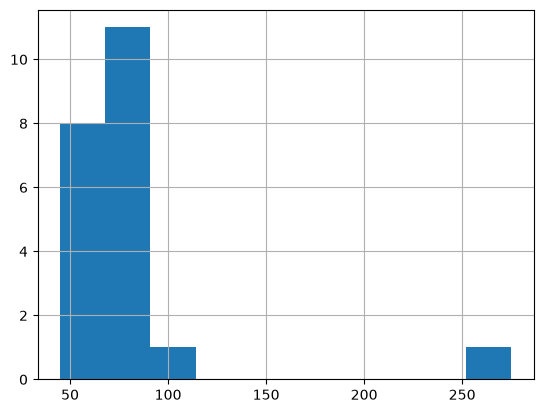

In [16]:
df['Marks'].hist()

<Axes: >

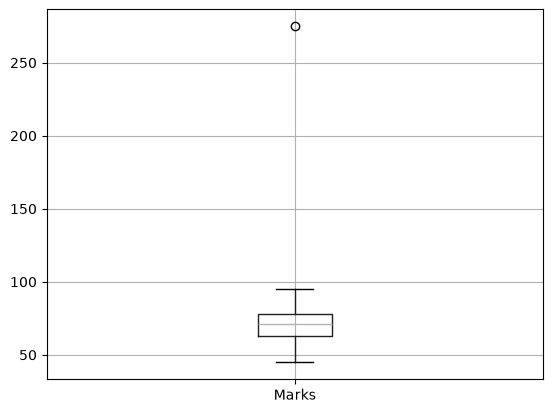

In [17]:
df.boxplot(column='Marks')

In [18]:
df['Marks'].skew()

np.float64(4.118656382820778)

# Univariate Analysis — Categorical Variables 📊

> Categorical variables represent groups/categories rather than measurable numerical values.

Examples: `Gender`, `City`, `Department`, `Payment_Method`

## Types

### Nominal
Categories with **no natural order**.

Examples: `City`, `Color`, `Payment_Method`

### Ordinal
Categories with a **meaningful order**.

Examples: `Poor < Average < Good < Excellent`

## Analysis

### Frequency
Number of observations in each category.

```python
df["Department"].value_counts()
````

### Percentage

```python
df["Department"].value_counts(normalize=True) * 100
```

→ percentage of observations in each category.

### Unique Categories

```python
df["Department"].unique()
```

→ actual categories

```python
df["Department"].nunique()
```

→ number of unique categories

### Most Frequent Category

```python
df["Department"].mode()[0]
```

→ most frequently occurring category

## Visualization

### Bar Chart

```python
df["Department"].value_counts().plot(kind="bar")
```

→ compares category frequencies.

### Pie Chart

```python
df["Department"].value_counts().plot(kind="pie", autopct="%1.1f%%")
```

→ shows category proportions.

## Important

Check:

* Frequency
* Percentage
* Number of unique categories
* Most frequent category
* Rare categories
* Class imbalance

## Quick Summary

```text
Nominal  → No natural order
Ordinal  → Meaningful order

value_counts()
→ Frequency

value_counts(normalize=True) * 100
→ Percentage

unique()
→ Actual categories

nunique()
→ Number of categories

Bar Chart
→ Category comparison
```

```
```


In [19]:
import pandas as pd

data = {
    "Customer_ID": range(1, 31),

    "Department": [
        "Electronics", "Fashion", "Electronics", "Home", "Fashion",
        "Electronics", "Beauty", "Home", "Fashion", "Electronics",
        "Home", "Beauty", "Electronics", "Fashion", "Home",
        "Electronics", "Beauty", "Fashion", "Electronics", "Home",
        "Fashion", "Electronics", "Home", "Beauty", "Fashion",
        "Electronics", "Home", "Fashion", "Electronics", "Beauty"
    ],

    "Membership": [
        "Gold", "Silver", "Bronze", "Gold", "Silver",
        "Gold", "Bronze", "Silver", "Gold", "Gold",
        "Bronze", "Silver", "Gold", "Bronze", "Silver",
        "Gold", "Gold", "Silver", "Bronze", "Gold",
        "Silver", "Gold", "Bronze", "Silver", "Gold",
        "Bronze", "Silver", "Gold", "Gold", "Bronze"
    ],

    "Payment_Method": [
        "UPI", "Card", "UPI", "Cash", "Card",
        "UPI", "Card", "UPI", "Cash", "Card",
        "UPI", "Card", "UPI", "Cash", "UPI",
        "Card", "UPI", "Cash", "Card", "UPI",
        "Cash", "Card", "UPI", "Card", "Cash",
        "UPI", "Card", "Cash", "UPI", "Card"
    ]
}

df = pd.DataFrame(data)

In [31]:
df.head()

,Customer_ID,Department,Membership,Payment_Method
0,1,Electronics,Gold,UPI
1,2,Fashion,Silver,Card
2,3,Electronics,Bronze,UPI
3,4,Home,Gold,Cash
4,5,Fashion,Silver,Card


In [32]:
print(df['Department'].value_counts(normalize = True) *100)
print()
print(df['Membership'].value_counts(normalize = True) *100)
print()
print(df['Payment_Method'].value_counts(normalize = True) *100)
print()

Department
Electronics    33.333333
Fashion        26.666667
Home           23.333333
Beauty         16.666667
Name: proportion, dtype: float64

Membership
Gold      43.333333
Silver    30.000000
Bronze    26.666667
Name: proportion, dtype: float64

Payment_Method
UPI     40.000000
Card    36.666667
Cash    23.333333
Name: proportion, dtype: float64



In [34]:
print(df['Department'].unique())
print(df['Department'].nunique())

<StringArray>
['Electronics', 'Fashion', 'Home', 'Beauty']
Length: 4, dtype: str
4


<Axes: xlabel='Department'>

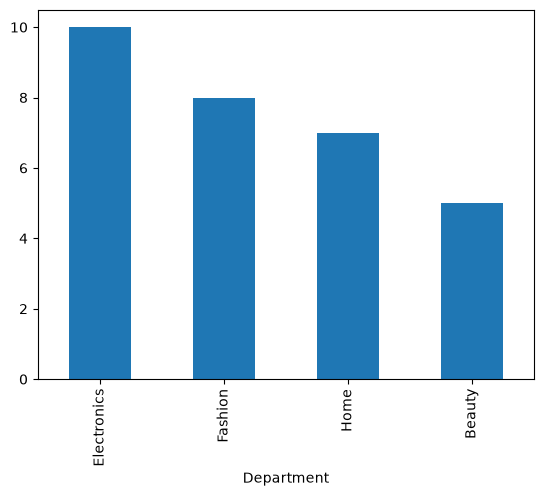

In [35]:
df["Department"].value_counts().plot(kind="bar")

<Axes: >

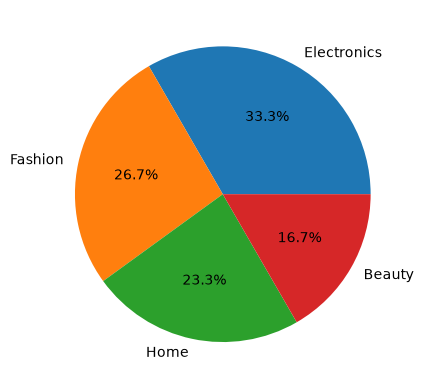

In [36]:
df["Department"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)